In [1]:
# 1. 라이브러리 import
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
# 2. 데이터 로드
df = pd.read_csv('../practice/pricerunner_aggregate.csv')

# 문제 1-1: 상위 5개 출력
print(df['Product Title'].head())

# 문제 1-2: 결측치 제거
df = df.dropna(subset=['Product Title'])

0                      apple iphone 8 plus 64gb silver
1                  apple iphone 8 plus 64 gb spacegrau
2    apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...
3                  apple iphone 8 plus 64gb space grey
4    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
Name: Product Title, dtype: str


In [3]:
# -----------------------------------
# 3. 텍스트 전처리
# -----------------------------------

def clean_text(text):
    text = text.lower()  # 소문자 변환
    text = re.sub(r'[^a-z0-9 ]', '', text)  # 알파벳, 숫자만 남김
    return text

df['clean_title'] = df['Product Title'].apply(clean_text)

print(df[['Product Title', 'clean_title']].head())

                                       Product Title  \
0                    apple iphone 8 plus 64gb silver   
1                apple iphone 8 plus 64 gb spacegrau   
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...   
3                apple iphone 8 plus 64gb space grey   
4  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...   

                                         clean_title  
0                    apple iphone 8 plus 64gb silver  
1                apple iphone 8 plus 64 gb spacegrau  
2  apple mq8n2ba iphone 8 plus 64gb 55 12mp sim f...  
3                apple iphone 8 plus 64gb space grey  
4  apple iphone 8 plus gold 55 64gb 4g unlocked s...  


In [4]:
# -----------------------------------
# 4. TF-IDF 벡터화
# -----------------------------------

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['clean_title'])

# 문제 3-1: 벡터 크기 출력
print("TF-IDF shape:", X.shape)

TF-IDF shape: (35311, 1000)


K=2, Silhouette Score=0.0203
K=3, Silhouette Score=0.0282
K=4, Silhouette Score=0.0356
K=5, Silhouette Score=0.0421
K=6, Silhouette Score=0.0422
K=7, Silhouette Score=0.0504
K=8, Silhouette Score=0.0574
K=9, Silhouette Score=0.0603
K=10, Silhouette Score=0.0587


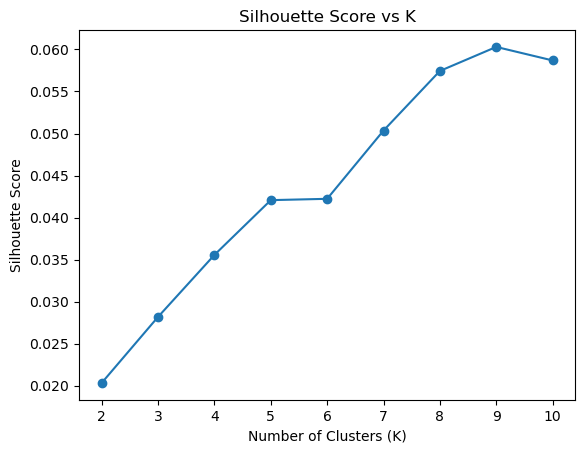

In [5]:
# -----------------------------------
# 5. Silhouette Score로 최적 K 찾기
# -----------------------------------

scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    scores.append(score)
    
    print(f"K={k}, Silhouette Score={score:.4f}")

# 문제 4-2: 시각화
plt.figure()
plt.plot(K_range, scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()

In [6]:
# -----------------------------------
# 6. 최적 K 선택 (보통 최고점)
# -----------------------------------

optimal_k = K_range[np.argmax(scores)]
print("Optimal K:", optimal_k)

Optimal K: 9


In [7]:
# -----------------------------------
# 7. KMeans 클러스터링
# -----------------------------------

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

print(df[['clean_title', 'cluster']].head())

                                         clean_title  cluster
0                    apple iphone 8 plus 64gb silver        0
1                apple iphone 8 plus 64 gb spacegrau        0
2  apple mq8n2ba iphone 8 plus 64gb 55 12mp sim f...        0
3                apple iphone 8 plus 64gb space grey        0
4  apple iphone 8 plus gold 55 64gb 4g unlocked s...        0


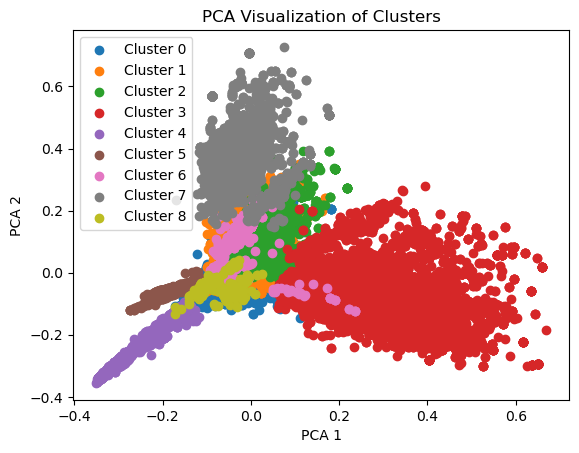

In [8]:
# -----------------------------------
# 8. PCA 2차원 시각화
# -----------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure()

for cluster in range(optimal_k):
    plt.scatter(
        X_pca[df['cluster'] == cluster, 0],
        X_pca[df['cluster'] == cluster, 1],
        label=f'Cluster {cluster}'
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA Visualization of Clusters')
plt.legend()
plt.show()